# 03 - XLM-RoBERTa Fine-Tuning for Taglish Sentiment Classification
**Project:** Sentiment Analysis of Taglish E-Commerce Reviews using Naive Bayes and XLM-RoBERTa  
**Notebook owner:** JODIMEER AMMANG (XLM-R Person)  
**Role:** Fine-tune `xlm-roberta-base` on FiReCS for 3-class sentiment classification.  

**First Part** Verify data pipeline, tokenizer, model loading, and sanity-check the forward pass.  
**Second Part** Full fine-tuning (2 epochs), evaluation, attention visualization.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

DRIVE_BASE     = "/content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project"
DATA_RAW       = f"{DRIVE_BASE}/data/firecs.csv"
DATA_PROCESSED = f"{DRIVE_BASE}/data/firecs_processed.csv"
OUTPUTS        = f"{DRIVE_BASE}/outputs"
FIGURES        = f"{DRIVE_BASE}/outputs/figures"
CHECKPOINTS    = f"{DRIVE_BASE}/checkpoints/xlmr-finetuned"
HF_CACHE       = f"{DRIVE_BASE}/cache"

os.makedirs(FIGURES, exist_ok=True)
os.makedirs(CHECKPOINTS, exist_ok=True)
os.makedirs(HF_CACHE, exist_ok=True)
os.environ["TRANSFORMERS_CACHE"] = HF_CACHE
os.environ["HF_HOME"]            = HF_CACHE

print("Paths configured.")
print(f"  Data:        {DATA_PROCESSED}")
print(f"  Outputs:     {OUTPUTS}")
print(f"  Checkpoints: {CHECKPOINTS}")

Paths configured.
  Data:        /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/data/firecs_processed.csv
  Outputs:     /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs
  Checkpoints: /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/checkpoints/xlmr-finetuned


In [ ]:
!pip install transformers datasets scikit-learn pandas matplotlib seaborn scipy accelerate -q

## 1. Load Processed Data
Load `firecs_processed.csv` produced by the Data person (Notebook 01).  
Expected columns: `text`, `label`, `split` (train/test).

In [3]:
import pandas as pd

df = pd.read_csv(DATA_PROCESSED)
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nSplit distribution:\n{df['split'].value_counts()}")
print(f"\nLabel distribution (overall):\n{df['label'].value_counts().sort_index()}")
print(f"\nLabel distribution by split:")
print(df.groupby('split')['label'].value_counts().unstack(fill_value=0))
print(f"\nSample rows:")
df.head()

Total rows: 10487
Columns: ['review', 'label', 'split']

Split distribution:
split
train    7340
test     3147
Name: count, dtype: int64

Label distribution (overall):
label
0    3408
1    3636
2    3443
Name: count, dtype: int64

Label distribution by split:
label     0     1     2
split                  
test   1027  1087  1033
train  2381  2549  2410

Sample rows:


,review,label,split
0,im very disappointed kasi di gumana ang dalawa...,0,train
1,10 10 it has minor damage when it was delivere...,1,train
2,super ganda then tama ung size and color sa uu...,2,train
3,we like it po madali naming na receive and goo...,2,train
4,walang picture and video nung product wala kas...,2,train


## 2. Build HuggingFace Dataset & Tokenize
Tokenize with `xlm-roberta-base` SentencePiece tokenizer, max_length=128.  
This matches Cosme & De Leon (2024) protocol.

In [4]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Log hardware
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
GPU Memory: 15.6 GB


In [5]:
from datasets import Dataset, DatasetDict

train_df = df[df['split'] == 'train'][['review', 'label']].reset_index(drop=True)
test_df  = df[df['split'] == 'test'][['review', 'label']].reset_index(drop=True)

dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df),
    'test':  Dataset.from_pandas(test_df),
})

print(dataset)
print(f"\nTrain sample: {dataset['train'][0]}")

DatasetDict({
    train: Dataset({
        features: ['review', 'label'],
        num_rows: 7340
    })
    test: Dataset({
        features: ['review', 'label'],
        num_rows: 3147
    })
})

Train sample: {'review': 'im very disappointed kasi di gumana ang dalawa kung order', 'label': 0}


In [6]:
from transformers import AutoTokenizer

MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir=HF_CACHE)

def tokenize_fn(batch):
    return tokenizer(batch['review'], padding='max_length', truncation=True, max_length=128)

tokenized = dataset.map(tokenize_fn, batched=True, batch_size=256)
tokenized = tokenized.remove_columns(['review'])
tokenized = tokenized.rename_column('label', 'labels')
tokenized.set_format('torch')

print(tokenized)
print(f"\nSample keys: {list(tokenized['train'][0].keys())}")
print(f"Input IDs shape: {tokenized['train'][0]['input_ids'].shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/7340 [00:00<?, ? examples/s]

Map:   0%|          | 0/3147 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 7340
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 3147
    })
})

Sample keys: ['labels', 'input_ids', 'attention_mask']
Input IDs shape: torch.Size([128])


## 3. Load Model & Sanity Check
Load `xlm-roberta-base` with a 3-class classification head.  
Run a 2-batch forward pass to confirm loss decreases (sanity check).

In [7]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    cache_dir=HF_CACHE,
)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     278,045,955
Trainable parameters: 278,045,955


In [8]:
from torch.utils.data import DataLoader

# Small dataloader for sanity check
sanity_loader = DataLoader(tokenized['train'].select(range(32)), batch_size=16, shuffle=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
model.train()

print("Sanity check — 2 batches, loss should decrease:")
for i, batch in enumerate(sanity_loader):
    batch = {k: v.to(device) for k, v in batch.items()}
    outputs = model(**batch)
    loss = outputs.loss
    print(f"  Batch {i+1}: loss = {loss.item():.4f}")
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

print("\n✓ Forward pass works. Loss decreasing confirms gradients flow correctly.")
print("  Day 1 XLM-R setup complete. Full training on Day 2.")

Sanity check — 2 batches, loss should decrease:
  Batch 1: loss = 1.1259
  Batch 2: loss = 1.0478

✓ Forward pass works. Loss decreasing confirms gradients flow correctly.
  Day 1 XLM-R setup complete. Full training on Day 2.


## Part 1 Status
- [x] Data loaded and verified (7,340 train / 3,147 test, 3 classes balanced)
- [x] Tokenizer: `xlm-roberta-base` SentencePiece, max_length=128
- [x] Model: `xlm-roberta-base` + 3-class head loaded on GPU
- [x] Sanity check: forward pass works, loss decreases

**Part 2:** Full fine-tuning, evaluation, attention visualization.

---
## Day 2 - Full Fine-Tuning & Evaluation

**Tasks:**
1. Fine-tune XLM-R: AdamW, lr=2e-5, 2 epochs, batch=16
2. Save checkpoints per epoch
3. Evaluate on test set (accuracy, weighted F1, per-class P/R/F1)
4. Replication check vs. Cosme & De Leon (2024) — target ~0.84 accuracy
5. Save `xlmr_predictions.csv`
6. Attention visualization on curated examples

In [9]:
# Reinitialize model with fresh weights (Day 1 sanity check modified a few steps)
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    cache_dir=HF_CACHE,
)
model.to(device)
print("✓ Fresh model loaded for training.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Fresh model loaded for training.


In [10]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1_weighted = f1_score(labels, preds, average='weighted')
    precision, recall, f1_per, _ = precision_recall_fscore_support(labels, preds, average=None)
    return {
        'accuracy': acc,
        'f1_weighted': f1_weighted,
        'precision_neg': precision[0], 'recall_neg': recall[0], 'f1_neg': f1_per[0],
        'precision_neu': precision[1], 'recall_neu': recall[1], 'f1_neu': f1_per[1],
        'precision_pos': precision[2], 'recall_pos': recall[2], 'f1_pos': f1_per[2],
    }

training_args = TrainingArguments(
    output_dir=CHECKPOINTS,
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    seed=SEED,
    fp16=True,
    report_to="none",
    load_best_model_at_end=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['test'],
    compute_metrics=compute_metrics,
)

print("✓ Trainer configured.")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  Weight decay: {training_args.weight_decay}")

✓ Trainer configured.
  Epochs: 2
  Batch size: 16
  Learning rate: 2e-05
  Weight decay: 0.01


### 4. Train
This will take ~15–25 minutes on a T4 GPU. Keep the Colab tab active.  
Checkpoints are saved to Drive after each epoch as insurance.

In [11]:
import time

start_time = time.time()
train_result = trainer.train()
train_time = time.time() - start_time

print(f"\n✓ Training complete in {train_time/60:.1f} minutes.")
print(f"  Final training loss: {train_result.training_loss:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Precision Neg,Recall Neg,F1 Neg,Precision Neu,Recall Neu,F1 Neu,Precision Pos,Recall Pos,F1 Pos
1,0.501406,0.476567,0.815062,0.811650,0.824811,0.848101,0.836294,0.785256,0.676173,0.726644,0.830303,0.928364,0.876600
2,0.399441,0.419523,0.832857,0.833544,0.861167,0.833496,0.847105,0.753304,0.786569,0.769577,0.893910,0.880929,0.887372


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Training complete in 7.4 minutes.
  Final training loss: 0.5275


### 5. Evaluate on Test Set
Report accuracy, weighted F1, per-class precision/recall/F1, and confusion matrix.  
**Replication target:** Cosme & De Leon (2024) report 0.84 accuracy — we should land within ~1 point.

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
predictions = trainer.predict(tokenized['test'])
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

label_names = ['Negative', 'Neutral', 'Positive']

# Classification report
print("=" * 60)
print("XLM-RoBERTa — Test Set Results")
print("=" * 60)
report = classification_report(labels, preds, target_names=label_names, digits=4)
print(report)

acc = accuracy_score(labels, preds)
f1_w = f1_score(labels, preds, average='weighted')
print(f"Accuracy:    {acc:.4f}")
print(f"Weighted F1: {f1_w:.4f}")

# Replication check
print("\n" + "-" * 60)
cosme_acc = 0.84
diff = abs(acc - cosme_acc)
status = "✓ PASS" if diff <= 0.02 else "✗ INVESTIGATE"
print(f"Replication check vs. Cosme & De Leon (2024):")
print(f"  Ours: {acc:.4f}   Theirs: {cosme_acc}   Δ = {diff:.4f}   [{status}]")
if diff > 0.02:
    print("  ⚠ Gap > 2 points. Audit preprocessing, tokenizer, lr, and seed before proceeding.")

XLM-RoBERTa — Test Set Results
              precision    recall  f1-score   support

    Negative     0.8612    0.8335    0.8471      1027
     Neutral     0.7533    0.7866    0.7696      1087
    Positive     0.8939    0.8809    0.8874      1033

    accuracy                         0.8329      3147
   macro avg     0.8361    0.8337    0.8347      3147
weighted avg     0.8347    0.8329    0.8335      3147

Accuracy:    0.8329
Weighted F1: 0.8335

------------------------------------------------------------
Replication check vs. Cosme & De Leon (2024):
  Ours: 0.8329   Theirs: 0.84   Δ = 0.0071   [✓ PASS]


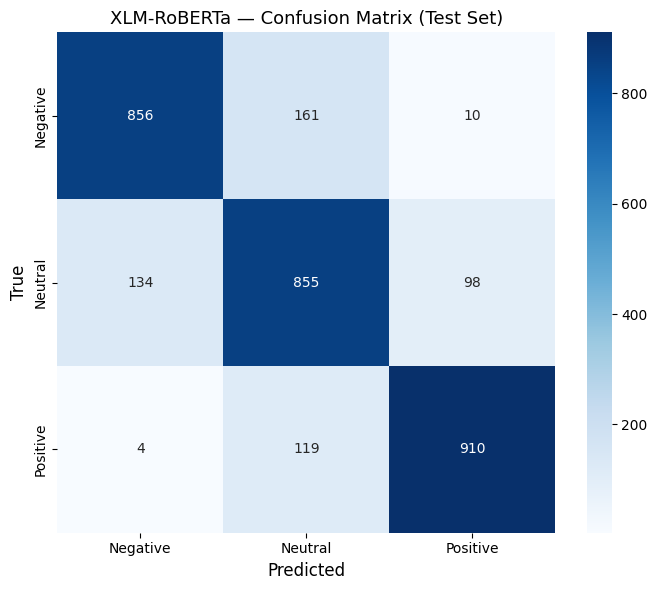

✓ Saved to /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs/figures/xlmr_confusion_matrix.png


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('XLM-RoBERTa — Confusion Matrix (Test Set)', fontsize=13)
plt.tight_layout()

save_path = f"{FIGURES}/xlmr_confusion_matrix.png"
fig.savefig(save_path, dpi=150)
plt.show()
print(f"✓ Saved to {save_path}")

In [14]:
# Build predictions DataFrame
test_df_out = df[df['split'] == 'test'][['review', 'label']].reset_index(drop=True)
test_df_out = test_df_out.rename(columns={'review': 'text', 'label': 'true_label'})
test_df_out['xlmr_pred'] = preds
test_df_out['xlmr_correct'] = (test_df_out['true_label'] == test_df_out['xlmr_pred']).astype(int)

pred_path = f"{OUTPUTS}/xlmr_predictions.csv"
test_df_out.to_csv(pred_path, index=False)

print(f"✓ Saved predictions to {pred_path}")
print(f"  Total: {len(test_df_out)}")
print(f"  Correct: {test_df_out['xlmr_correct'].sum()} ({test_df_out['xlmr_correct'].mean():.4f})")
print(f"\nSample:")
test_df_out.head()

✓ Saved predictions to /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs/xlmr_predictions.csv
  Total: 3147
  Correct: 2621 (0.8329)

Sample:


,text,true_label,xlmr_pred,xlmr_correct
0,okay naman kaso maliit size e adjust nyona lan...,1,1,1
1,good seller sends out photo before shipping ma...,2,2,1
2,di cya gano kabilis sa net loading and loading...,1,1,1
3,green ang order ko black ang dumating pero gre...,0,0,1
4,no scam po di deliver sa akin yunq parcel ko t...,0,2,0


### 6. Attention Visualization
Extract attention weights for 5 correctly classified and 5 misclassified reviews.  
Visualize which tokens XLM-R attends to — this feeds into RQ4b.

In [15]:
# Separate correct and incorrect predictions
correct_mask = test_df_out['xlmr_correct'] == 1
incorrect_mask = test_df_out['xlmr_correct'] == 0

correct_df = test_df_out[correct_mask]
incorrect_df = test_df_out[incorrect_mask]

print(f"Correct predictions:   {len(correct_df)}")
print(f"Incorrect predictions: {len(incorrect_df)}")

# Pick 5 correct and 5 incorrect — try to get a mix of classes
np.random.seed(SEED)

correct_samples = pd.concat([
    correct_df[correct_df['true_label'] == 0].sample(2, random_state=SEED),
    correct_df[correct_df['true_label'] == 1].sample(1, random_state=SEED),
    correct_df[correct_df['true_label'] == 2].sample(2, random_state=SEED),
])

incorrect_samples = incorrect_df.sample(min(5, len(incorrect_df)), random_state=SEED)

curated = pd.concat([correct_samples, incorrect_samples]).reset_index(drop=True)
curated['category'] = ['correct'] * len(correct_samples) + ['incorrect'] * len(incorrect_samples)

print(f"\nCurated {len(curated)} examples for attention visualization:")
for i, row in curated.iterrows():
    snippet = row['text'][:80] + "..." if len(row['text']) > 80 else row['text']
    print(f"  [{row['category']:>9}] true={row['true_label']} pred={row['xlmr_pred']} | {snippet}")

Correct predictions:   2621
Incorrect predictions: 526

Curated 10 examples for attention visualization:
  [  correct] true=0 pred=0 | hindi po ngccharge yung earbuds sana nagrereply din kayo sa inquiries ng mga cus...
  [  correct] true=0 pred=0 | mali ung binigay sakin na case ang inorder cu stictch ang pinadala nasa
  [  correct] true=1 pred=1 | good product is in good quality although medyo maluwag ang silicon dunno why and...
  [  correct] true=2 pred=2 | i bought it for my friend kaya di ako napag pic pero na try ko sya at super smoo...
  [  correct] true=2 pred=2 | items received are complete no damage dahil maganda ang pagkabalot mura na at ma...
  [incorrect] true=2 pred=1 | correct color and size malapad sya kaya nde bagay sa mga payat ang paa kasi malu...
  [incorrect] true=0 pred=1 | akala ko mystery pouch pareho pa binigay haha
  [incorrect] true=2 pred=1 | good na gustohan ko kase makapal sya hindi masisira agad thank you seller
  [incorrect] true=1 pred=0 | naka angat un

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Attention-enabled model loaded with fine-tuned weights.


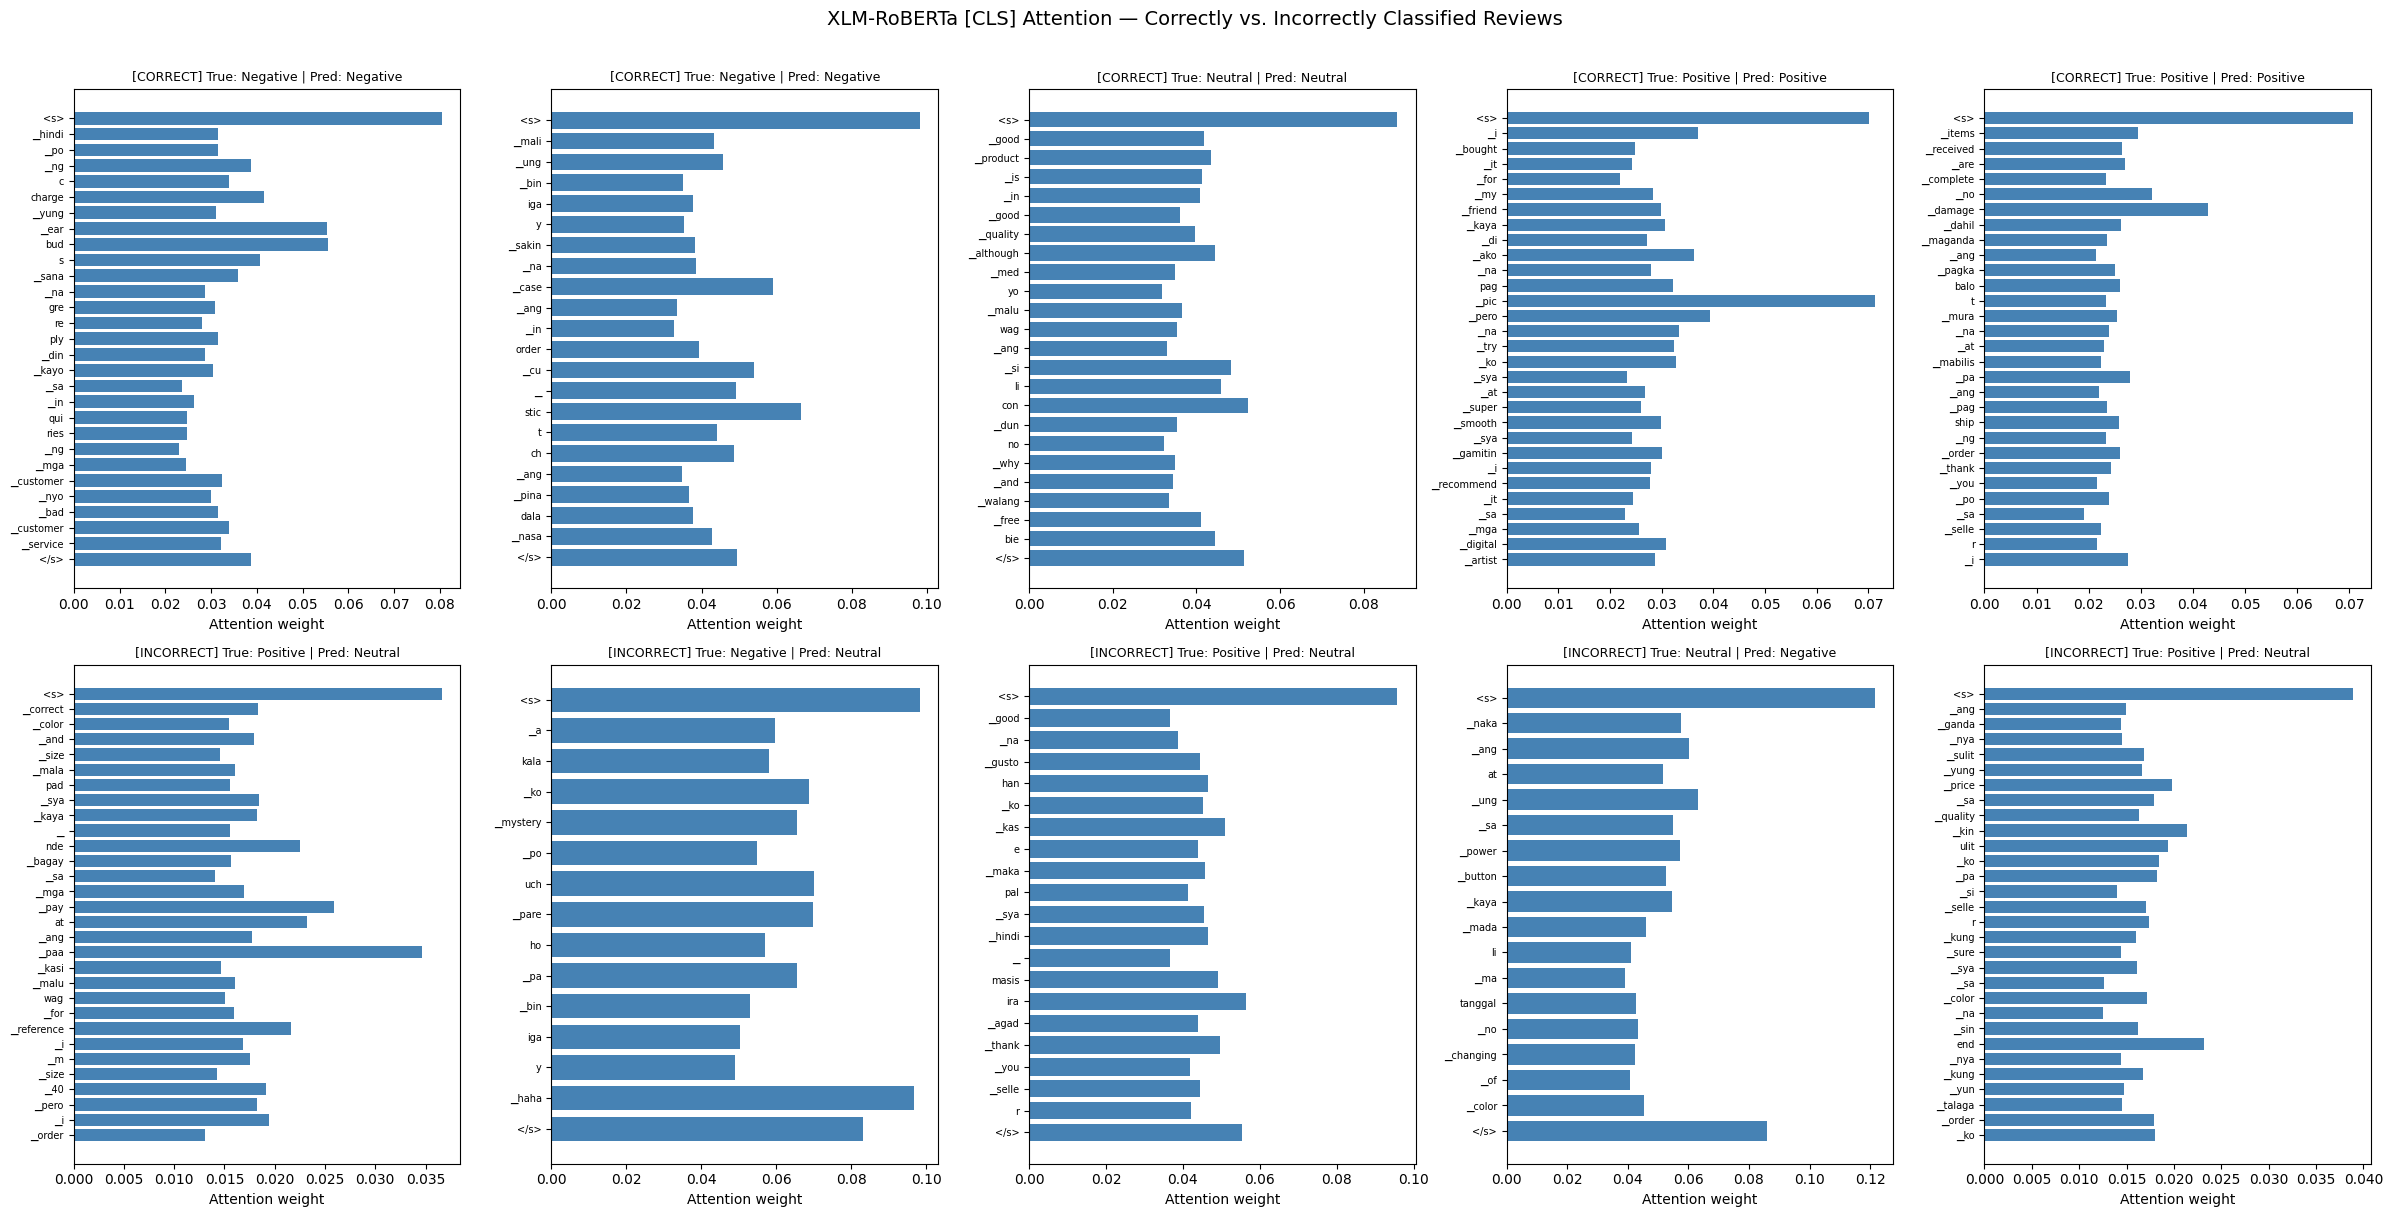

✓ Saved to /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs/figures/xlmr_attention_examples.png


In [ ]:
from transformers import AutoModelForSequenceClassification
import torch
import matplotlib.pyplot as plt
import numpy as np

# Reload model with output_attentions enabled in config
attn_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    cache_dir=HF_CACHE,
    output_attentions=True,
)

# Load the fine-tuned weights from the trainer into this model
attn_model.load_state_dict(model.state_dict())
attn_model.to(device)
attn_model.eval()
print("✓ Attention-enabled model loaded with fine-tuned weights.")


def get_attention(text, tokenizer, model, device):
    """Extract attention weights for a single input text."""
    inputs = tokenizer(
        text, return_tensors='pt', truncation=True,
        max_length=128, padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    attentions = outputs.attentions  # tuple: (num_layers,) each (1, heads, seq, seq)
    assert attentions is not None, "Attentions are None — check model config."

    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    # Average across all heads in the last layer → (seq_len, seq_len)
    last_layer_attn = attentions[-1][0].mean(dim=0).cpu().numpy()

    # CLS token's attention over the sequence
    cls_attn = last_layer_attn[0]

    return tokens, cls_attn, last_layer_attn


def plot_cls_attention(tokens, cls_attn, title, ax):
    """Plot CLS token attention as a horizontal bar chart."""
    # Trim padding tokens
    non_pad = [i for i, t in enumerate(tokens) if t != '<pad>']
    tokens_trimmed = [tokens[i] for i in non_pad]
    attn_trimmed = [cls_attn[i] for i in non_pad]

    # Limit to first 30 tokens for readability
    max_show = 30
    tokens_show = tokens_trimmed[:max_show]
    attn_show = attn_trimmed[:max_show]

    y_pos = range(len(tokens_show))
    ax.barh(y_pos, attn_show, color='steelblue')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(tokens_show, fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel('Attention weight')
    ax.set_title(title, fontsize=9)


# Generate attention plots for all curated examples
n_examples = len(curated)
fig, axes = plt.subplots(2, 5, figsize=(24, 12))
axes = axes.flatten()

for i, (_, row) in enumerate(curated.iterrows()):
    if i >= 10:
        break
    tokens, cls_attn, _ = get_attention(row['text'], tokenizer, attn_model, device)

    true_lbl = label_names[row['true_label']]
    pred_lbl = label_names[row['xlmr_pred']]
    tag = row['category'].upper()
    title = f"[{tag}] True: {true_lbl} | Pred: {pred_lbl}"

    plot_cls_attention(tokens, cls_attn, title, axes[i])

# Hide unused subplots if fewer than 10 examples
for j in range(n_examples, 10):
    axes[j].axis('off')

plt.suptitle(
    "XLM-RoBERTa [CLS] Attention — Correctly vs. Incorrectly Classified Reviews",
    fontsize=14, y=1.01
)
plt.tight_layout()

save_path = f"{FIGURES}/xlmr_attention_examples.png"
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved to {save_path}")

In [ ]:
import json

metadata = {
    "model": MODEL_NAME,
    "num_labels": 3,
    "epochs": 2,
    "batch_size": 16,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "max_seq_length": 128,
    "seed": SEED,
    "train_samples": len(tokenized['train']),
    "test_samples": len(tokenized['test']),
    "training_time_minutes": round(train_time / 60, 1),
    "test_accuracy": round(acc, 4),
    "test_f1_weighted": round(f1_w, 4),
    "device": str(device),
    "gpu_name": torch.cuda.get_device_name(0) if device.type == "cuda" else "N/A",
}

meta_path = f"{OUTPUTS}/xlmr_training_metadata.json"
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print("Training metadata:")
for k, v in metadata.items():
    print(f"  {k}: {v}")
print(f"\n✓ Saved to {meta_path}")

Training metadata:
  model: xlm-roberta-base
  num_labels: 3
  epochs: 2
  batch_size: 16
  learning_rate: 2e-05
  weight_decay: 0.01
  max_seq_length: 128
  seed: 42
  train_samples: 7340
  test_samples: 3147
  training_time_minutes: 7.4
  test_accuracy: 0.8329
  test_f1_weighted: 0.8335
  device: cuda
  gpu_name: Tesla T4

✓ Saved to /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs/xlmr_training_metadata.json


## Day 2 Status
- [x] Full fine-tuning complete (2 epochs, AdamW, lr=2e-5, batch=16)
- [x] Checkpoints saved to Drive
- [x] Test set evaluation: accuracy, weighted F1, per-class P/R/F1
- [x] Replication check vs. Cosme & De Leon (2024)
- [x] Confusion matrix saved
- [x] `xlmr_predictions.csv` saved
- [x] Attention visualization on 10 curated examples saved
- [x] Training metadata logged

**Next:** Manuscript Lead uses `xlmr_predictions.csv` + `nb_predictions.csv` in Notebook 04 for comparison analysis (Day 3).